# Selecting Highly Deviant Bins
Now that we have a working function to calculate deviance, we'll want to tranform this information in such a way that we can extract the most highly deviant bins and perform UOT based on those.

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and Files ###
root = '../../../'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
data_dir_immune = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'

In [98]:
### Imports ###
import sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_calculate_deviance, fetch_region

In [5]:
### Importing coolers ###
clrs = import_cool_dir(data_dir)
clrs_immune = import_cool_dir(data_dir_immune)

## Helper Functions

### Visualisation

In [68]:
def vis_deviance(
        deviance : pd.DataFrame,
        title : str
    ):
    '''
        Takes a pandas dataframe describing deviance per bins
        and visualizes this as a heatmap.

        Parameters
        ----------
        deviance : pd.Dataframe
            Dataframe describing deviance per bins
            given as a multi index.
        title : str
            Title to use.
    '''

    heatmap_data = (
        deviance["deviances"]
        .unstack(level="bin_j")
        .reindex(index=range(250), columns=range(250))
    )
    plt.figure(figsize=(8,6))
    plt.imshow(heatmap_data, origin='upper', cmap='viridis', aspect='auto')
    plt.colorbar(label='deviance')
    plt.title(title, fontweight='bold')
    plt.xlim(left=0, right=250)
    plt.ylim(bottom=250, top=0)
    plt.xlabel("bin_j")
    plt.ylabel("bin_i")
    plt.tight_layout()
    return

## Selecting Top Bins

### Calculating

In [6]:
### Cell Lines Deviance ###
lines_deviance = hic_calculate_deviance(clrs, "chr1")
lines_deviance

deviances
bin_i bin_j            
241   248    141.911439
4     14     141.260077
204   209    140.186180
4     13     139.651279
3     14     139.603138
...                 ...
126   186      0.000000
      187      0.000000
      188      0.000000
      189      0.000000
73    138      0.000000

[31375 rows x 1 columns]

In [12]:
### Immune Cells Deviance ###
immune_deviance = hic_calculate_deviance(clrs_immune, "chr1")
immune_deviance

deviances
bin_i bin_j            
207   211    531.116218
188   190    511.942175
108   109    492.776211
234   235    381.845943
228   230    326.042663
...                 ...
141   176      0.000000
      175      0.000000
      174      0.000000
      173      0.000000
21    124      0.000000

[31125 rows x 1 columns]

### Histograms

Text(0.5, 1.0, 'Deviance in Cell Lines Bins')

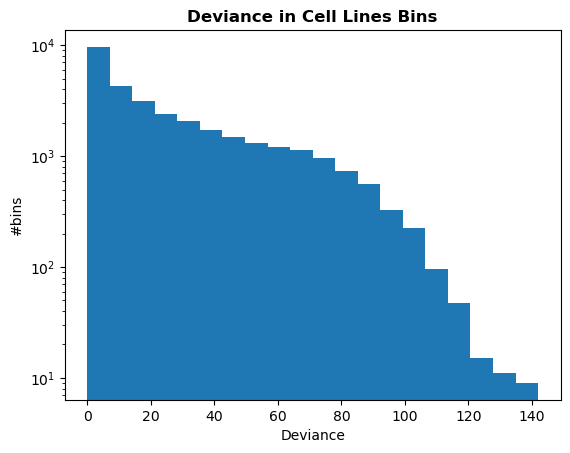

In [14]:
### Cell Lines Hist ###
plt.hist(lines_deviance["deviances"], log=True, bins=20)
plt.ylabel("#bins")
plt.xlabel("Deviance")
plt.title("Deviance in Cell Lines Bins", fontweight='bold')

Text(0.5, 1.0, 'Deviance in Immune Cells Bins')

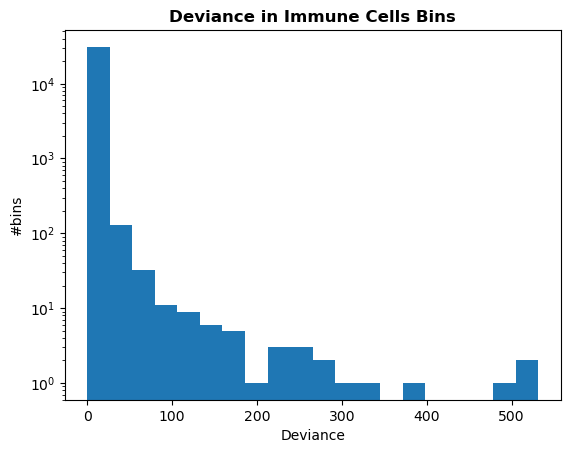

In [15]:
### Immune Cells ###
plt.hist(immune_deviance["deviances"], log=True, bins=20)
plt.ylabel("#bins")
plt.xlabel("Deviance")
plt.title("Deviance in Immune Cells Bins", fontweight='bold')

### Selecting Top Coordinates and Visualizing
Looking at the histograms, we can define some kind of deviance threshold. For testing purposes here, we'll set the threshold at 100

In [49]:
### Coordinates, Cell Lines ###
lines_highly_deviant = lines_deviance[lines_deviance['deviances'] > 100]
lines_highly_deviant

,,deviances
bin_i,bin_j,
241,248,141.911439
4,14,141.260077
204,209,140.186180
4,13,139.651279
3,14,139.603138
...,...,...
239,243,100.069858
47,53,100.066922
11,18,100.052144


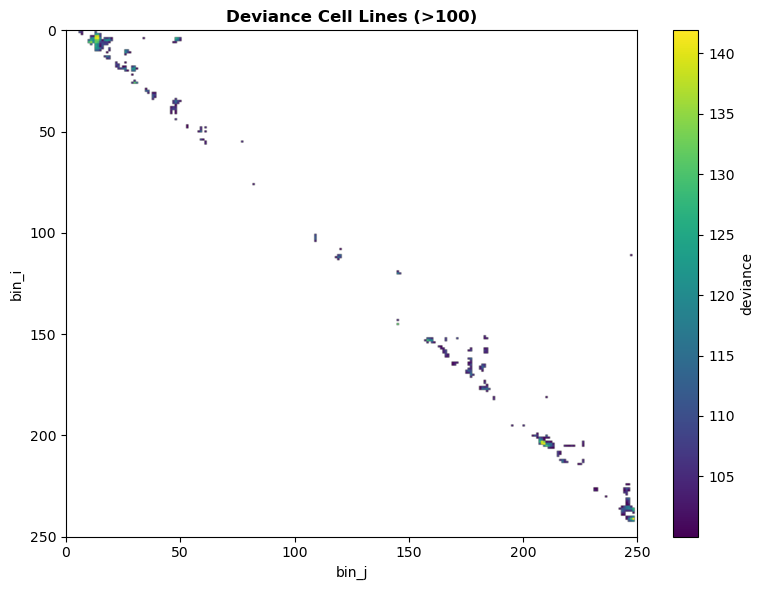

In [70]:
### Visualizing, Cell Lines ###
vis_deviance(lines_highly_deviant, "Deviance Cell Lines (>100)")

This may still be too sparse to perform acceptable optimal transport. We'd have to either perform deviance selection on binned data to allow for more data to be selected or impose some kind of restraint to select points that aren't near one another.

In [66]:
### Coordinates, Immune Cells ###
immune_highly_deviant = immune_deviance[immune_deviance['deviances'] > 100]
immune_highly_deviant

,,deviances
bin_i,bin_j,
207,211,531.116218
188,190,511.942175
108,109,492.776211
234,235,381.845943
228,230,326.042663
102,103,303.150814
99,100,288.232887
207,208,286.314093
221,221,262.169953


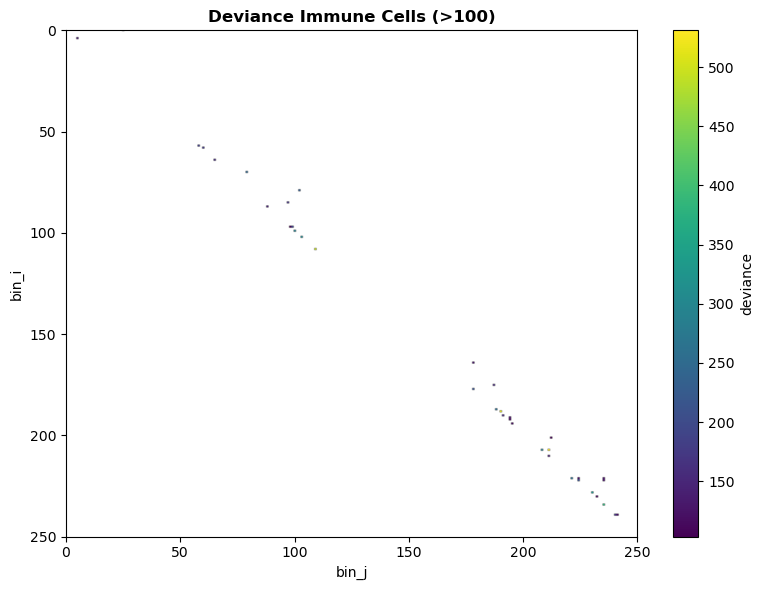

In [69]:
### Visualizing, Cell Lines ###
vis_deviance(immune_highly_deviant, "Deviance Immune Cells (>100)")

### Extracting Coordinates Only
We need a function to extract only the coordinates to be used for optimal transport.

In [80]:
lines_highly_deviant.index.values

array([(241, 248), (4, 14), (204, 209), (4, 13), (3, 14), (203, 208),
       (204, 208), (3, 13), (6, 11), (5, 14), (203, 209), (6, 13),
       (5, 13), (26, 30), (145, 145), (205, 210), (241, 247), (6, 14),
       (153, 158), (6, 10), (236, 248), (203, 207), (5, 11), (4, 48),
       (8, 13), (2, 14), (7, 13), (237, 248), (4, 12), (5, 18), (19, 30),
       (205, 211), (9, 13), (9, 14), (153, 159), (2, 13), (19, 29),
       (5, 19), (6, 12), (11, 26), (4, 15), (202, 207), (4, 49),
       (153, 160), (240, 248), (242, 248), (7, 14), (5, 12), (5, 48),
       (8, 14), (5, 17), (236, 246), (236, 247), (120, 145), (205, 209),
       (4, 11), (235, 246), (19, 26), (204, 210), (5, 15), (177, 184),
       (13, 18), (235, 245), (241, 246), (112, 119), (236, 245), (10, 26),
       (35, 48), (213, 217), (204, 211), (202, 208), (5, 49), (242, 247),
       (20, 30), (170, 177), (204, 212), (20, 29), (177, 182), (9, 15),
       (18, 30), (50, 59), (10, 13), (26, 31), (5, 10), (166, 182),
       (231,

In [81]:
immune_highly_deviant.index.values

array([(207, 211), (188, 190), (108, 109), (234, 235), (228, 230),
       (102, 103), (99, 100), (207, 208), (221, 221), (187, 188),
       (70, 79), (79, 102), (177, 178), (222, 224), (97, 99), (57, 58),
       (58, 60), (239, 240), (85, 97), (64, 65), (190, 191), (175, 187),
       (0, 25), (87, 88), (4, 5), (210, 211), (164, 178), (221, 235),
       (191, 194), (222, 235), (221, 224), (194, 195), (239, 241),
       (230, 232), (192, 194), (201, 212), (97, 98)], dtype=object)

### Extracting Top Number
Instead of setting a deviance threshold, it'd alternatively be nice to be able to extract the top number of deviant coordinates.

In [83]:
### Top 250 deviant coordinates, cell lines ###
lines_deviance.head(250)

,,deviances
bin_i,bin_j,
241,248,141.911439
4,14,141.260077
204,209,140.186180
4,13,139.651279
3,14,139.603138
...,...,...
56,61,103.824383
171,177,103.774657
156,163,103.710009


In [84]:
### Top 250 deviant coordinates, immune ###
immune_deviance.head(250)

,,deviances
bin_i,bin_j,
207,211,531.116218
188,190,511.942175
108,109,492.776211
234,235,381.845943
228,230,326.042663
...,...,...
188,194,23.356701
85,93,23.226195
60,74,23.053228


## Extracting weights
OT also requires us to extract the weights (read counts) of each point.

In [97]:
### Cell Lines ###
    # Extracting region for one cooler
lines_chr1 = fetch_region(clrs[0], 'chr1')
lines_indices_250 = lines_deviance.head(250).index

    # Extracting values
lines_values = [] 
for i, j in lines_indices_250:
    lines_values.append(lines_chr1[i, j])
lines_values 

[np.float64(0.217622),
 np.float64(0.788449),
 np.float64(0.971003),
 np.float64(0.684895),
 np.float64(0.806188),
 np.float64(0.953549),
 np.float64(0.976991),
 np.float64(0.677832),
 np.float64(0.924577),
 np.float64(0.830113),
 np.float64(0.907284),
 np.float64(0.89618),
 np.float64(0.749465),
 np.float64(0.21727),
 np.float64(1.008451),
 np.float64(0.97895),
 np.float64(0.424788),
 np.float64(0.966131),
 np.float64(0.758318),
 np.float64(1.019819),
 np.float64(0.461685),
 np.float64(0.780975),
 np.float64(0.771237),
 np.float64(0.024315),
 np.float64(0.894814),
 np.float64(0.784325),
 np.float64(0.953418),
 np.float64(0.543478),
 np.float64(0.652066),
 np.float64(0.726451),
 np.float64(0.55384),
 np.float64(0.974714),
 np.float64(0.752898),
 np.float64(0.905304),
 np.float64(0.538663),
 np.float64(0.686359),
 np.float64(0.61289),
 np.float64(0.631641),
 np.float64(0.998554),
 np.float64(0.594953),
 np.float64(0.707504),
 np.float64(0.71101),
 np.float64(0.052956),
 np.float64(0.329

In [ ]:
### Immune Cells ###
    # Extracting region for one cooler
immune_chr1 = fetch_region(clrs_immune[0], 'chr1')
immune_indices_250 = immune_deviance.head(250).index

    # Extracting values
immune_values = [] 
for i, j in immune_indices_250:
    immune_values.append(immune_chr1[i, j])
immune_values

[np.float64(0.051516),
 np.float64(0.074215),
 np.float64(0.046174),
 np.float64(0.036952),
 np.float64(0.011593),
 np.float64(0.037205),
 np.float64(0.039571),
 np.float64(0.024012),
 np.float64(0.061227),
 np.float64(0.021414),
 np.float64(0.036081),
 np.float64(0.025616),
 np.float64(0.036429),
 np.float64(0.006872),
 np.float64(0.001345),
 np.float64(0.004659),
 np.float64(0.000177),
 np.float64(0.028818),
 np.float64(0.021272),
 np.float64(0.030079),
 np.float64(0.005288),
 np.float64(0.005309),
 np.float64(0.006155),
 np.float64(0.010912),
 np.float64(0.001377),
 np.float64(0.003893),
 np.float64(0.015607),
 np.float64(0.000816),
 np.float64(0.016891),
 np.float64(0.001009),
 np.float64(0.001577),
 np.float64(0.004642),
 np.float64(0.03185),
 np.float64(0.001401),
 np.float64(0.052655),
 np.float64(0.010635),
 np.float64(0.006549),
 np.float64(0.000886),
 np.float64(0.000573),
 np.float64(0.008927),
 np.float64(0.007417),
 np.float64(0.00075),
 np.float64(0.009858),
 np.float64(0